# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print(missing_pct)


# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

`alive` chỉ là `survived` được viết lại dưới dạng chữ ("yes"/"no") thay vì số (1/0) — nó **là cùng một thông tin**, không phải một đặc trưng độc lập được biết trước khi biết kết quả. Nếu giữ `alive` làm đặc trưng đầu vào, mô hình chỉ cần học một quy tắc ánh xạ tầm thường (yes→1, no→0) là đạt accuracy ~100% trên mọi tập dữ liệu, kể cả test.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print("Số dòng, số cột:", df.shape)
print("Biến mục tiêu (target): 'survived' (1 = sống sót, 0 = tử vong)\n")

df.info()

print("\n--- Thống kê biến số (describe) ---")
display(df.describe())

print("\n--- Thống kê biến phân loại (describe include=object) ---")
display(df.describe(include=["string"]))

Số dòng, số cột: (891, 8)
Biến mục tiêu (target): 'survived' (1 = sống sót, 0 = tử vong)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB

--- Thống kê biến số (describe) ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Thống kê biến phân loại (describe include=object) ---


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- *Biến số (numerical)*: `survived` (nhị phân 0/1, thực chất là phân loại nhưng lưu dạng số), `pclass` (số thứ tự 1/2/3), `age`, `sibsp`, `parch`, `fare`.
- *Biến phân loại (categorical)*: `sex` (male/female), `embarked` (C/Q/S).

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
miss = df.isnull().sum()
miss = miss[miss > 0]
missing_table = pd.DataFrame({
    "so_luong_thieu": miss,
    "phan_tram_thieu": (miss / len(df) * 100).round(2)
}).sort_values("phan_tram_thieu", ascending=False)
display(missing_table)

,so_luong_thieu,phan_tram_thieu
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | ~19.9% | Điền **median** | Tỷ lệ thiếu vừa phải (không quá lớn nên không bỏ cột), nhưng `age` có outlier (người rất già/rất trẻ) nên median bền vững hơn mean, tránh bị outlier kéo lệch giá trị điền vào. |
| embarked | ~0.2% | Điền **mode** (giá trị xuất hiện nhiều nhất là "S") | Là biến phân loại nên không thể tính mean/median; tỷ lệ thiếu cực nhỏ nên điền mode gần như không ảnh hưởng tới phân phối tổng thể. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
from pyparsing import col


def dem_outlier_iqr(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < low) | (s > high)).sum())    # trả về số lượng outlier theo IQR

def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return int((z > nguong).sum())    # trả về số lượng outlier theo Z-score

for col in ["age", "fare"]:
    print(f"{col}: IQR = {dem_outlier_iqr(df[col])} outlier | Z-score = {dem_outlier_zscore(df[col])} outlier")


age: IQR = 11 outlier | Z-score = 2 outlier
fare: IQR = 116 outlier | Z-score = 20 outlier


**Trả lời 4 (quyết định với outlier của `fare`):**

Nên **giữ lại** phần lớn các outlier của `fare`. Vé đắt bất thường rất có khả năng là **hiện tượng thật** chứ không phải lỗi nhập liệu. Thực tế, giá vé tương quan chặt với `pclass` và với khả năng sống sót (hành khách hạng nhất có tỷ lệ sống sót cao hơn hẳn), nên loại bỏ các outlier này sẽ làm **mất thông tin có giá trị dự đoán**. Thay vì loại bỏ dùng một scaler bền vững với outlier như `RobustScaler`.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

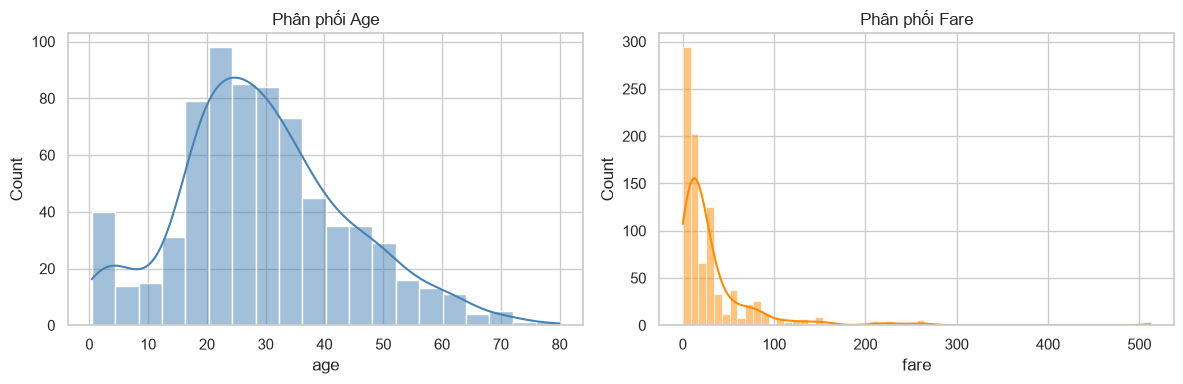

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["age"].dropna(), kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Phân phối Age")
sns.histplot(df["fare"].dropna(), kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Phân phối Fare")
plt.tight_layout()
plt.show()

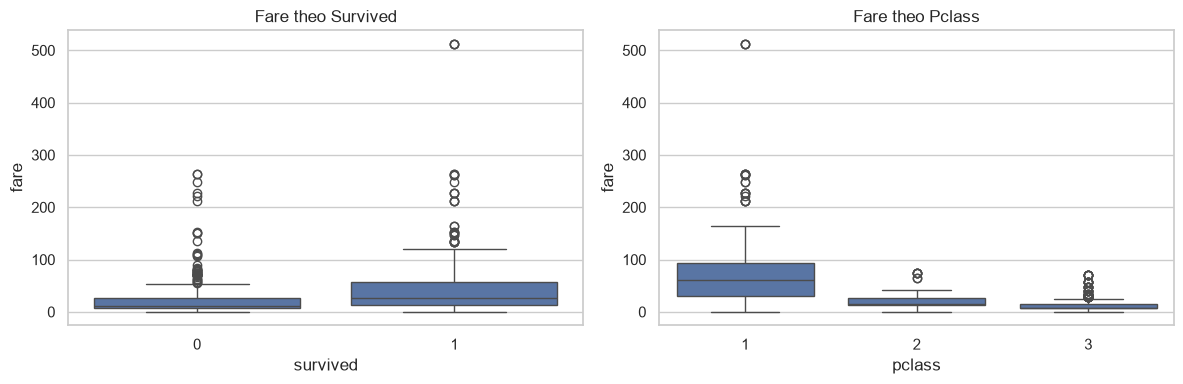

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="survived", y="fare", ax=axes[0])
axes[0].set_title("Fare theo Survived")
sns.boxplot(data=df, x="pclass", y="fare", ax=axes[1])
axes[1].set_title("Fare theo Pclass")
plt.tight_layout()
plt.show()

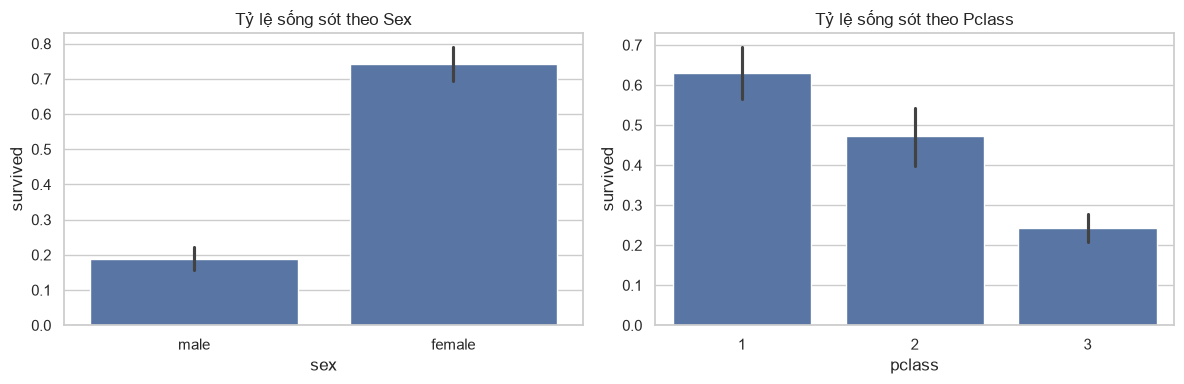

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Tỷ lệ sống sót theo Sex")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1])
axes[1].set_title("Tỷ lệ sống sót theo Pclass")
plt.tight_layout()
plt.show()

display(df.groupby("sex")["survived"].mean())
display(df.groupby("pclass")["survived"].mean())


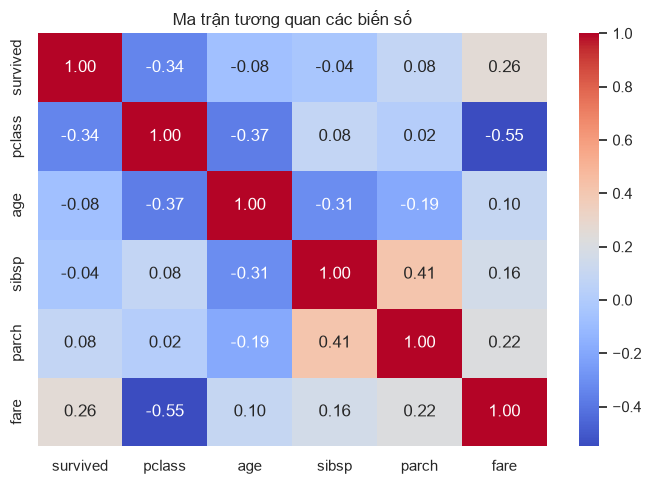

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(7, 5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ma trận tương quan các biến số")
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram:  `age` xấp xỉ phân phối chuẩn, hơi lệch phải nhẹ, tập trung nhiều ở khoảng 20–40 tuổi. `fare` lệch phải rất mạnh — đa số vé rẻ (dưới ~30), nhưng có đuôi dài các vé rất đắt (hạng nhất), kéo mean lên cao hơn median nhiều.
- Boxplot: nhóm `survived=1` có fare trung vị cao hơn và nhiều outlier giá cao hơn nhóm `survived=0`, cho thấy hành khách trả vé đắt (thường là pclass 1) sống sót nhiều hơn. Boxplot theo `pclass` cho thấy fare giảm dần rõ rệt từ hạng 1 → 2 → 3, và pclass 1 có nhiều outlier fare cực cao.
- Bar survival: nữ giới có tỷ lệ sống sót (~74%) cao hơn hẳn nam giới (~19%), chênh lệch hơn 50% — phù hợp chính sách "phụ nữ và trẻ em trước". Theo pclass, hạng 1 có tỷ lệ sống sót cao nhất (~63%), giảm dần ở hạng 2 (~47%) và thấp nhất ở hạng 3 (~24%).
- Heatmap: `fare` và `pclass` tương quan âm mạnh nhất trong các biến số (khoảng -0.55, vì pclass 1 = hạng cao = số nhỏ nhưng giá cao). `survived` tương quan âm với `pclass` (khoảng -0.34) và tương quan dương với `fare` (khoảng 0.26) — hai đặc trưng này gắn khá chặt với khả năng sống sót hơn `sibsp`/`parch`/`age`.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp, random_state=42
)

print("Train/Val/Test shape:", X_train.shape, X_val.shape, X_test.shape)
print("Tỷ lệ sống sót - train:", y_train.mean().round(4))
print("Tỷ lệ sống sót - val:  ", y_val.mean().round(4))
print("Tỷ lệ sống sót - test: ", y_test.mean().round(4))


Train/Val/Test shape: (623, 7) (134, 7) (134, 7)
Tỷ lệ sống sót - train: 0.3836
Tỷ lệ sống sót - val:   0.3881
Tỷ lệ sống sót - test:  0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [15]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)
print(f"X_train_t.shape: {X_train_t.shape}")
print(f"Feature names: {list(preprocess.get_feature_names_out())}")

X_train_t.shape: (623, 10)
Feature names: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

`SimpleImputer` học median/mode, `RobustScaler` học median/IQR, và `OneHotEncoder` học danh sách các category — tất cả đều là **tham số được học từ dữ liệu**. Nếu `fit` trên toàn bộ dataset (bao gồm cả val/test) rồi mới chia tập, thì các tham số này đã "nhìn thấy" thông tin phân phối của val/test trước khi mô hình được đánh giá trên chúng — dẫn đến rò rỉ dữ liệu (data leakage) ở mức tiền xử lý. Hậu quả là kết quả đánh giá trên val/test sẽ **mang kết quả ảo**, không phản ánh đúng hiệu năng thực tế khi mô hình gặp dữ liệu hoàn toàn mới. Bằng cách `fit` chỉ trên `X_train` rồi dùng `transform` (không `fit` lại) cho val/test, ta mô phỏng đúng tình huống triển khai thực tế: mô hình chỉ được phép "biết" những gì học được từ tập huấn luyện.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
display(y.value_counts())
display(y.value_counts(normalize=True).round(4))

survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64

**Trả lời 8:**

1. `survived` **mất cân bằng nhẹ**: khoảng 62% không sống sót (lớp 0) và 38% sống sót (lớp 1) — tỷ lệ xấp xỉ 1.6:1 đủ để cần lưu ý.
2. Chỉ nhìn **Accuracy** có thể bị đánh lừa vì một mô hình "ngây thơ" luôn dự đoán lớp đa số (không sống sót) cũng đạt accuracy ~62% mà không học được gì hữu ích — accuracy cao không có nghĩa mô hình phân biệt tốt hai lớp, đặc biệt nếu nó gần như bỏ qua lớp thiểu số (sống sót).
3. Với bài toán Titanic, nên ưu tiên **F1-score** hơn là chỉ Accuracy, vì dữ liệu mất cân bằng và cả hai loại lỗi đều đáng quan tâm: bỏ sót người thực sự sống sót (Recall thấp) và dự đoán sai người tử vong thành sống sót (Precision thấp) đều mang ý nghĩa phân tích khác nhau. F1 cân bằng cả hai, phù hợp hơn khi không có lý do rõ ràng để ưu tiên tuyệt đối Precision hay Recall.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. **`sex` và `pclass` (qua `fare`) là hai đặc trưng tương quan mạnh nhất với khả năng sống sót**: nữ giới sống sót ~74% so với ~19% ở nam giới; hành khách hạng 1 sống sót ~63% so với ~24% ở hạng 3 — minh chứng rõ nét cho chính sách "phụ nữ và trẻ em trước" cùng lợi thế của hành khách giàu có.
2. Cột thiếu nhiều nhất ban đầu là **`deck`** (~77%) — đã loại bỏ hẳn vì thiếu quá nhiều để điền có ý nghĩa; cột **`age`** thiếu ~20% được điền bằng **median** (bền vững với outlier); **`embarked`** thiếu 2 dòng (~0.2%) được điền bằng **mode**.
3. Biến mục tiêu **có mất cân bằng nhẹ** (62% / 38%), nên **Accuracy đơn thuần không đủ tin cậy** — cần bổ sung F1-score khi đánh giá mô hình sau này.
4. Các đặc trưng **số** (`age`, `sibsp`, `parch`, `fare`) cần **scaling** vì thang đo khác nhau rất lớn (fare dao động 0–512 trong khi sibsp/parch chỉ 0–8), đặc biệt `fare` cần scaler bền vững với outlier (`RobustScaler`); các đặc trưng **phân loại** (`sex`, `embarked`) cần **one-hot encoding** vì không có thứ tự tự nhiên; riêng `pclass` tuy là số nhưng mang tính thứ tự nên giữ nguyên (passthrough).
5. Điều bất ngờ/thú vị: **giá vé (`fare`) có độ lệch phải cực mạnh** với một số ít vé đắt gấp hàng chục lần trung vị — đây không phải nhiễu mà phản ánh đúng cấu trúc xã hội trên tàu, và chính khoảng cách giàu-nghèo đó lại là một trong những yếu tố dự đoán sống-chết mạnh nhất, cho thấy dữ liệu "khô khan" vẫn có thể kể một câu chuyện xã hội rất rõ ràng.


---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
